In [1]:
# HealthGuard AI - Hypertension Model Training
# Author: HealthGuard AI Team
# Date: 2026
# Version: 2.0

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report,
                             roc_curve, auc)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     StratifiedKFold)
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8')

print("=" * 50)
print("  HealthGuard AI - Hypertension Model Training v2.0")
print("=" * 50)
print("Libraries Loaded Successfully!")

  HealthGuard AI - Hypertension Model Training v2.0
Libraries Loaded Successfully!


In [2]:
# Load Data

X_train = pd.read_csv("E:/HealthGuard_AI/data/processed/hypertension_X_train.csv")
X_test = pd.read_csv("E:/HealthGuard_AI/data/processed/hypertension_X_test.csv")
y_train = pd.read_csv("E:/HealthGuard_AI/data/processed/hypertension_y_train.csv").values.ravel()
y_test = pd.read_csv("E:/HealthGuard_AI/data/processed/hypertension_y_test.csv").values.ravel()

print("Data Loaded Successfully!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"\nTraining Class Distribution:")
print(f"No Hypertension: {(y_train==0).sum()}")
print(f"Hypertension: {(y_train==1).sum()}")

Data Loaded Successfully!
X_train Shape: (1610, 10)
X_test Shape: (389, 10)

Training Class Distribution:
No Hypertension: 805
Hypertension: 805


STEP 1: CROSS VALIDATION (5-FOLD)
Cross Validation Results:
----------------------------------------

Logistic Regression:
  Mean F1: 0.8338
  Std F1:  0.0291
  Scores:  [0.7843 0.8224 0.8696 0.852  0.8405]

Random Forest:
  Mean F1: 0.9662
  Std F1:  0.0167
  Scores:  [0.9649 0.9346 0.9811 0.9781 0.9721]

XGBoost:
  Mean F1: 0.9876
  Std F1:  0.0070
  Scores:  [0.9875 0.9753 0.9875 0.9969 0.9907]

SVM:
  Mean F1: 0.8945
  Std F1:  0.0246
  Scores:  [0.8839 0.8746 0.9201 0.9273 0.8667]

Neural Network:
  Mean F1: 0.9046
  Std F1:  0.0294
  Scores:  [0.8952 0.8667 0.947  0.9292 0.8848]


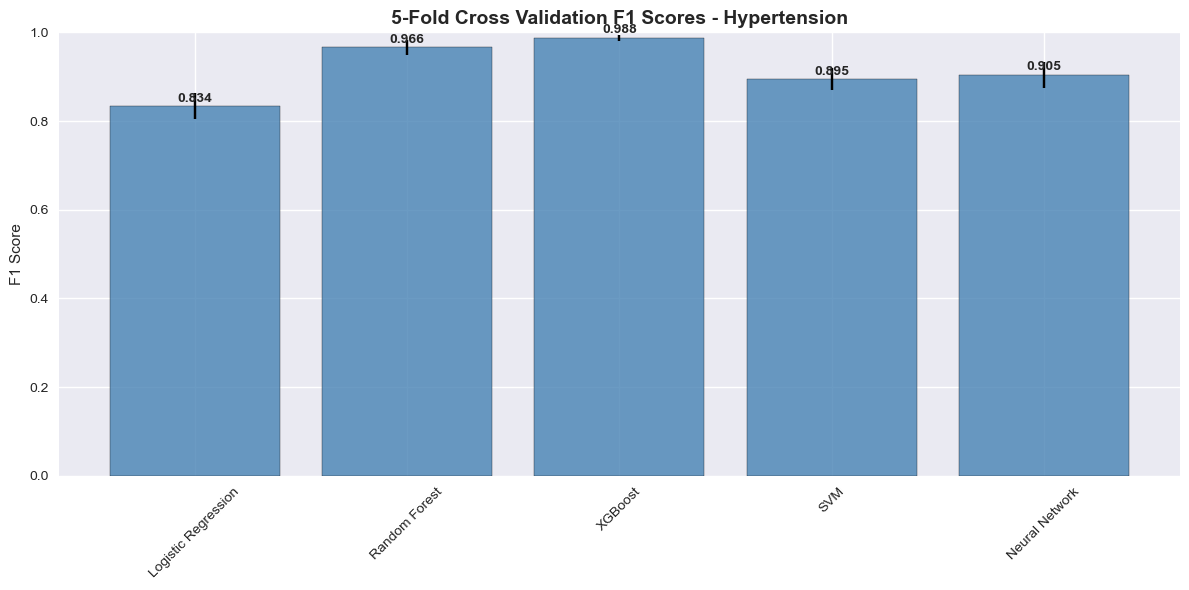

In [3]:
# Step 1: Cross Validation

print("=" * 50)
print("STEP 1: CROSS VALIDATION (5-FOLD)")
print("=" * 50)

cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

base_models = {
    'Logistic Regression': LogisticRegression(random_state=42,
                                              max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100,
                                           random_state=42),
    'XGBoost': XGBClassifier(random_state=42,
                              eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50),
                                    max_iter=500,
                                    random_state=42)
}

cv_results = {}

print("Cross Validation Results:")
print("-" * 40)

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1')
    cv_results[name] = {
        'Mean F1': cv_scores.mean(),
        'Std F1': cv_scores.std(),
        'All Scores': cv_scores
    }
    print(f"\n{name}:")
    print(f"  Mean F1: {cv_scores.mean():.4f}")
    print(f"  Std F1:  {cv_scores.std():.4f}")
    print(f"  Scores:  {cv_scores.round(4)}")

plt.figure(figsize=(12, 6))
names = list(cv_results.keys())
means = [cv_results[n]['Mean F1'] for n in names]
stds = [cv_results[n]['Std F1'] for n in names]

bars = plt.bar(names, means, yerr=stds,
               color='steelblue', edgecolor='black',
               capsize=5, alpha=0.8)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', fontweight='bold')

plt.title('5-Fold Cross Validation F1 Scores - Hypertension',
          fontweight='bold', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Step 2: Hyperparameter Tuning
# Restricted parameters to prevent overfitting

print("=" * 50)
print("STEP 2: HYPERPARAMETER TUNING")
print("=" * 50)

print("Tuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF F1: {rf_grid.best_score_:.4f}")

print("\nTuning XGBoost...")
# Restricted XGBoost params to prevent overfitting
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3],           # Shallow trees
    'learning_rate': [0.01, 0.05], # Low learning rate
    'subsample': [0.6, 0.7],       # Less data per tree
    'colsample_bytree': [0.6, 0.7],# Less features per tree
    'reg_alpha': [0.1, 0.5],       # L1 regularization
    'reg_lambda': [1.0, 2.0],      # L2 regularization
    'min_child_weight': [5, 10]    # Minimum samples in leaf
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"Best XGB F1: {xgb_grid.best_score_:.4f}")

print("\nHyperparameter Tuning Complete!")

STEP 2: HYPERPARAMETER TUNING
Tuning Random Forest...
Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF F1: 0.9682

Tuning XGBoost...
Best XGB Params: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.6}
Best XGB F1: 0.9852

Hyperparameter Tuning Complete!


In [5]:
# Step 3: Train Final Models with Regularization

print("=" * 50)
print("STEP 3: TRAIN FINAL MODELS")
print("=" * 50)

final_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000,
        C=0.1),                    # Regularization added
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'SVM': SVC(probability=True,
               random_state=42,
               C=0.5),             # Regularization added
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(50, 25),# Smaller network
        max_iter=500,
        random_state=42,
        alpha=0.01)                # L2 regularization
}

results = {}

for name, model in final_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC ROC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Model': model
    }

    print(f"Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"F1 Score:  {results[name]['F1 Score']:.4f}")
    print(f"AUC ROC:   {results[name]['AUC ROC']:.4f}")

print("\nAll Models Trained!")

STEP 3: TRAIN FINAL MODELS

Training Logistic Regression...
Accuracy:  0.8021
F1 Score:  0.8080
AUC ROC:   0.8995

Training Random Forest...
Accuracy:  0.9794
F1 Score:  0.9799
AUC ROC:   0.9990

Training XGBoost...
Accuracy:  0.9897
F1 Score:  0.9900
AUC ROC:   0.9994

Training SVM...
Accuracy:  0.9126
F1 Score:  0.9163
AUC ROC:   0.9662

Training Neural Network...
Accuracy:  0.8895
F1 Score:  0.8954
AUC ROC:   0.9691

All Models Trained!


                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.8021     0.8141  0.8020    0.8080   0.8995
Random Forest          0.9794     0.9949  0.9653    0.9799   0.9990
XGBoost                0.9897     0.9950  0.9851    0.9900   0.9994
SVM                    0.9126     0.9118  0.9208    0.9163   0.9662
Neural Network         0.8895     0.8804  0.9109    0.8954   0.9691


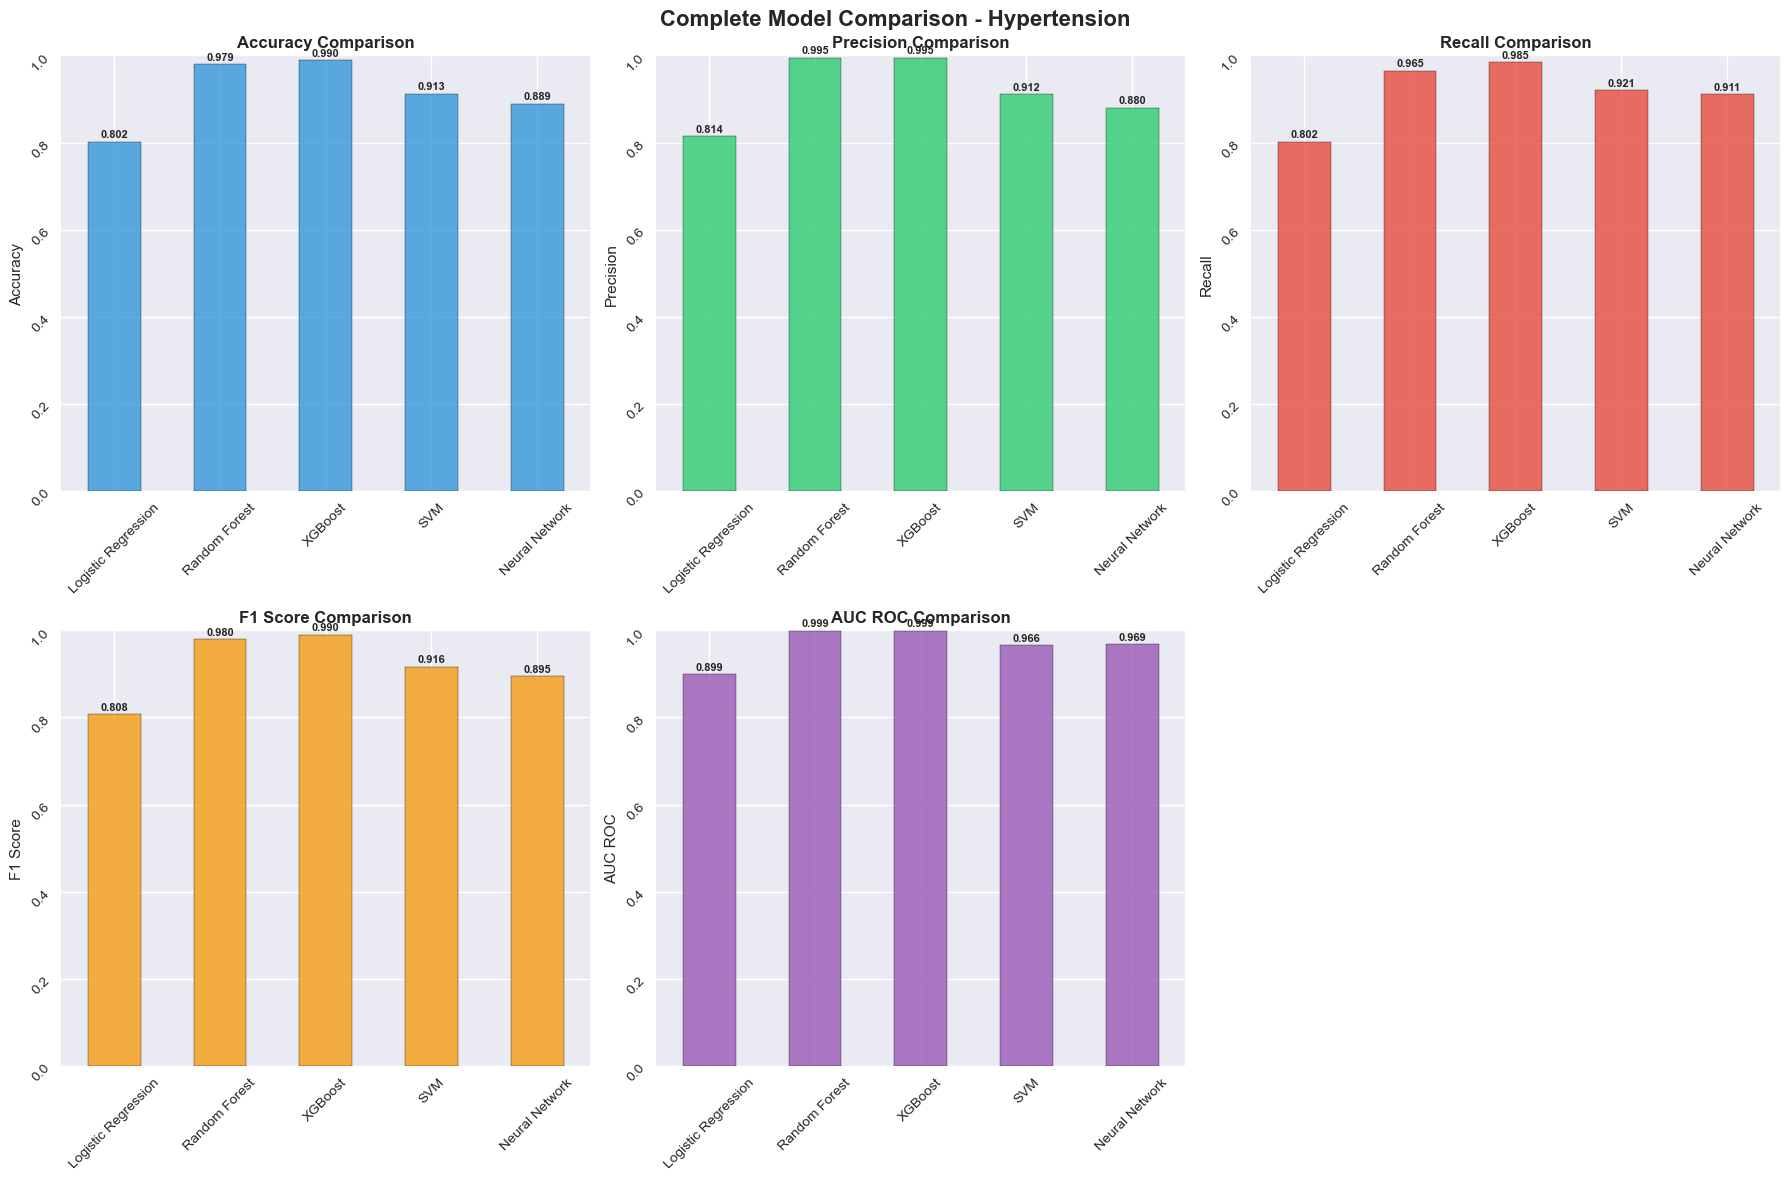

In [6]:
# Step 4: Model Comparison

results_df = pd.DataFrame({
    name: {
        'Accuracy': results[name]['Accuracy'],
        'Precision': results[name]['Precision'],
        'Recall': results[name]['Recall'],
        'F1 Score': results[name]['F1 Score'],
        'AUC ROC': results[name]['AUC ROC']
    }
    for name in results
}).T.round(4)

print(results_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall',
           'F1 Score', 'AUC ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c',
          '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar',
                            ax=axes[i],
                            color=colors[i],
                            edgecolor='black',
                            alpha=0.8)
    axes[i].set_title(f'{metric} Comparison',
                      fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(rotation=45)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=8,
                    fontweight='bold')

axes[5].set_visible(False)

plt.suptitle('Complete Model Comparison - Hypertension',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

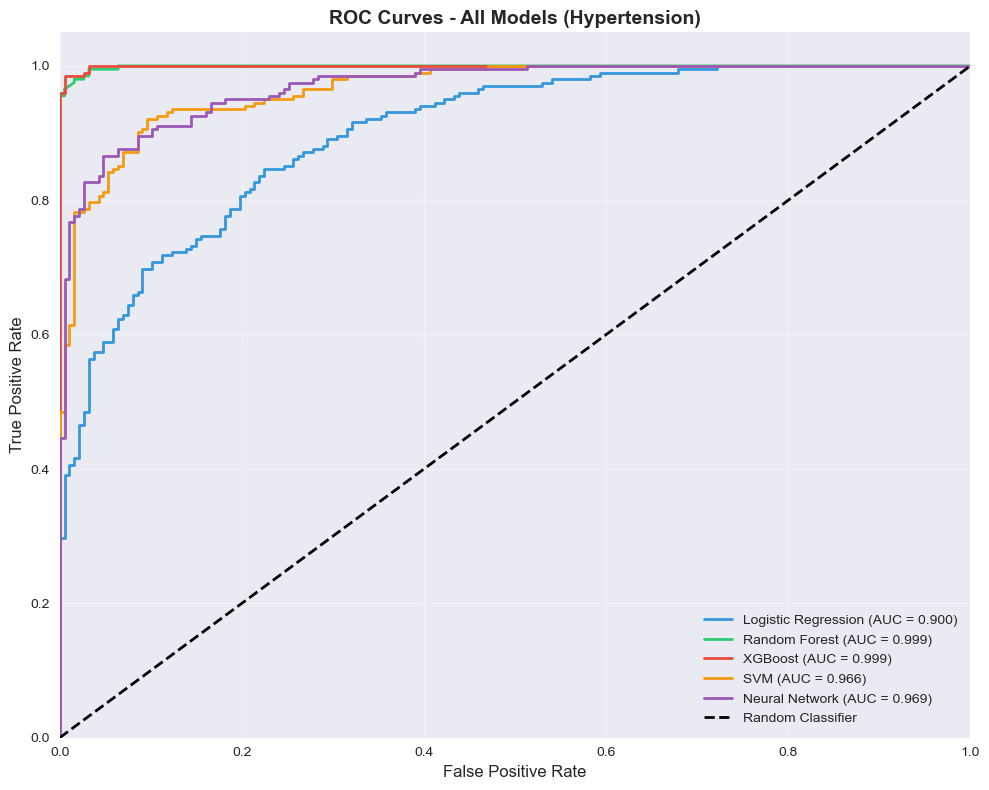

In [7]:
# Step 5: ROC Curve

plt.figure(figsize=(10, 8))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c',
              '#f39c12', '#9b59b6']

for (name, result), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2,
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Hypertension)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best Model: XGBoost
Accuracy:  0.9897
Precision: 0.9950
Recall:    0.9851
F1 Score:  0.9900
AUC ROC:   0.9994


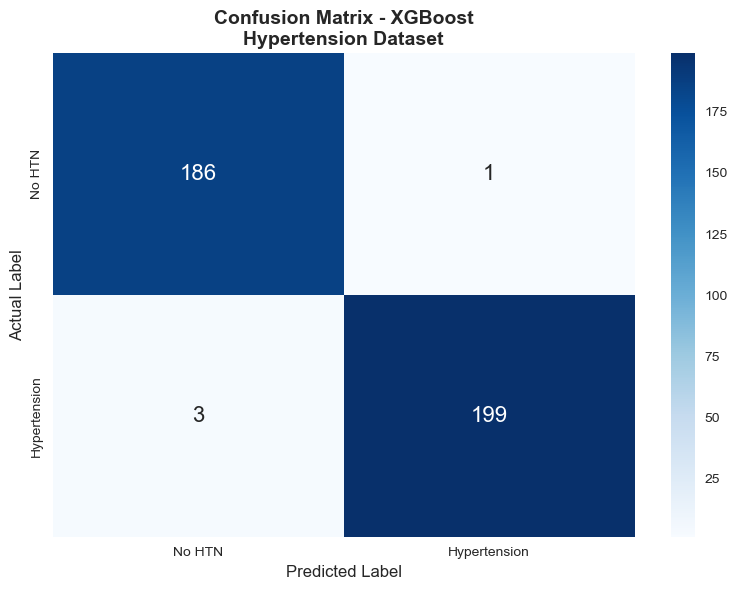

              precision    recall  f1-score   support

      No HTN       0.98      0.99      0.99       187
Hypertension       0.99      0.99      0.99       202

    accuracy                           0.99       389
   macro avg       0.99      0.99      0.99       389
weighted avg       0.99      0.99      0.99       389



In [8]:
# Step 6: Best Model & Confusion Matrix

best_model_name = results_df['F1 Score'].idxmax()
best_model = results[best_model_name]['Model']
y_pred_best = results[best_model_name]['y_pred']

print(f"Best Model: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No HTN', 'Hypertension'],
            yticklabels=['No HTN', 'Hypertension'],
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - {best_model_name}\n'
          f'Hypertension Dataset',
          fontweight='bold', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best,
      target_names=['No HTN', 'Hypertension']))

STEP 7: SHAP EXPLAINABILITY


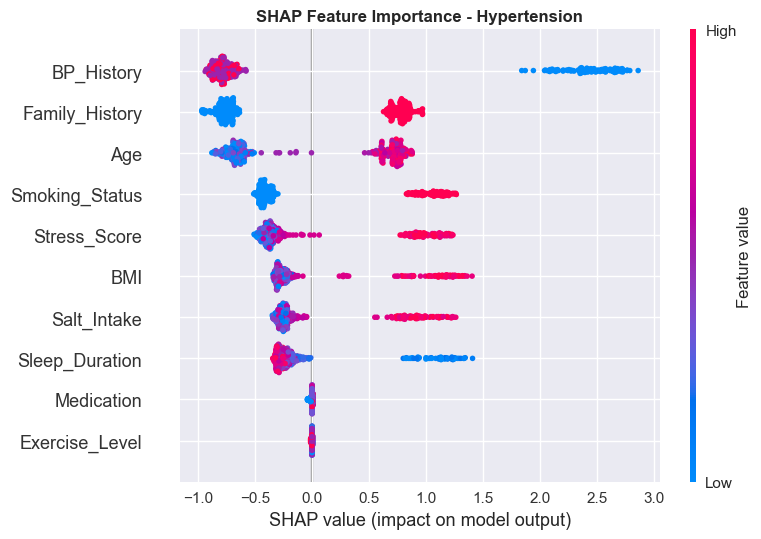

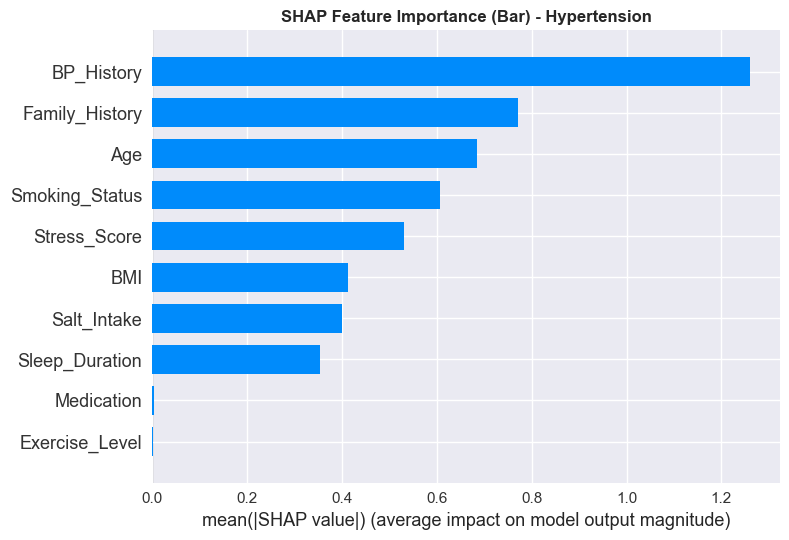

SHAP Analysis Complete!

Top Features by SHAP:
BP_History        1.260505
Family_History    0.771644
Age               0.684494
Smoking_Status    0.607409
Stress_Score      0.531459
BMI               0.413779
Salt_Intake       0.400018
Sleep_Duration    0.353757
Medication        0.004602
Exercise_Level    0.001722
dtype: float32


In [9]:
# Step 7: SHAP Explainability

print("=" * 50)
print("STEP 7: SHAP EXPLAINABILITY")
print("=" * 50)

if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.KernelExplainer(
        best_model.predict_proba,
        shap.sample(X_train, 100))

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance - Hypertension',
          fontweight='bold')
plt.tight_layout()
plt.savefig('E:/HealthGuard_AI/reports/hypertension_shap.png',
            dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Bar) - Hypertension',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("SHAP Analysis Complete!")
shap_importance = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_train.columns
).sort_values(ascending=False)
print("\nTop Features by SHAP:")
print(shap_importance)

In [10]:
# Step 8: Save Model

model_path = "E:/HealthGuard_AI/models/saved/hypertension_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test[:5])
print(f"Model: {best_model_name}")
print(f"Saved at: {model_path}")
print(f"Verification: {test_pred}")
print("Model Saved and Verified!")

Model: XGBoost
Saved at: E:/HealthGuard_AI/models/saved/hypertension_model.pkl
Verification: [1 0 0 0 1]
Model Saved and Verified!


In [11]:
# Final Summary

print("=" * 60)
print("   HYPERTENSION MODEL TRAINING - FINAL SUMMARY")
print("=" * 60)

print("\nCROSS VALIDATION RESULTS:")
print("-" * 40)
for name, cv in cv_results.items():
    print(f"{name}: {cv['Mean F1']:.4f} (+/- {cv['Std F1']:.4f})")

print("\nFINAL MODEL PERFORMANCE:")
print("-" * 40)
print(results_df.to_string())

print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

print(f"\nModel saved: hypertension_model.pkl")
print("\nHypertension Model Training Complete! ")
print("=" * 60)

   HYPERTENSION MODEL TRAINING - FINAL SUMMARY

CROSS VALIDATION RESULTS:
----------------------------------------
Logistic Regression: 0.8338 (+/- 0.0291)
Random Forest: 0.9662 (+/- 0.0167)
XGBoost: 0.9876 (+/- 0.0070)
SVM: 0.8945 (+/- 0.0246)
Neural Network: 0.9046 (+/- 0.0294)

FINAL MODEL PERFORMANCE:
----------------------------------------
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.8021     0.8141  0.8020    0.8080   0.8995
Random Forest          0.9794     0.9949  0.9653    0.9799   0.9990
XGBoost                0.9897     0.9950  0.9851    0.9900   0.9994
SVM                    0.9126     0.9118  0.9208    0.9163   0.9662
Neural Network         0.8895     0.8804  0.9109    0.8954   0.9691

BEST MODEL: XGBoost
Accuracy:  0.9897
Precision: 0.9950
Recall:    0.9851
F1 Score:  0.9900
AUC ROC:   0.9994

Model saved: hypertension_model.pkl

Hypertension Model Training Complete! 
